# Model Implementation: Indirect Prompt Injection Detection

Este notebook entrena y evalúa clasificadores ML clásicos para detectar indirect prompt injection.

**Inputs (de notebook 02):**
- `features/X_linguistic.pkl` — 10 features lingüísticas handcrafted
- `features/df_linguistic.pkl` — DataFrame con nombres de features
- `data/indirect_prompt_injection_bipia_gpt_train.csv` — dataset original (para labels y TF-IDF)

**Estructura:**
1. Carga de Artifactos
2. Feature Sets (Linguistic + TF-IDF)
3. Train/Test Split
4. Entrenamiento y Evaluación de Modelos
5. Comparativa de Resultados (modelos)
6. Analisis de Errores
7. Mejor modelo o fine tuning (preguntar)

In [54]:
import re
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, issparse

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Imports OK")

Imports OK


---
## Seccion 1 - Carga de Artifactos

In [55]:
def resolve_path(candidates):
    for p in candidates:
        if Path(p).exists():
            return Path(p)
    raise FileNotFoundError(f"None of {candidates} found")

DATA_PATH = resolve_path([
    "../data/indirect_prompt_injection_bipia_gpt_train.csv",
    "data/indirect_prompt_injection_bipia_gpt_train.csv",
])
FEATURES_DIR = resolve_path(["../features", "features"])
MODELS_DIR = Path(FEATURES_DIR.parent / "models")
MODELS_DIR.mkdir(exist_ok=True)

print(f"Data:     {DATA_PATH}")
print(f"Features: {FEATURES_DIR}")
print(f"Models:   {MODELS_DIR}")

Data:     ../data/indirect_prompt_injection_bipia_gpt_train.csv
Features: ../features
Models:   ../models


In [56]:
# Cargar dataset original (para labels y texto)
df = pd.read_csv(DATA_PATH)
y = df["label"].values

print(f"Dataset shape: {df.shape}")
print(f"Labels: {np.bincount(y)} (0=benign, 1=malicious)")

# Cargar features lingüísticas del notebook 02
X_linguistic = joblib.load(FEATURES_DIR / "X_linguistic.pkl")
df_linguistic = joblib.load(FEATURES_DIR / "df_linguistic.pkl")

LINGUISTIC_FEATURES = list(df_linguistic.columns)
print(f"\nX_linguistic shape: {X_linguistic.shape}")
print(f"Feature names: {LINGUISTIC_FEATURES}")

Dataset shape: (70000, 4)
Labels: [35000 35000] (0=benign, 1=malicious)

X_linguistic shape: (70000, 10)
Feature names: ['char_count', 'word_count', 'avg_word_length', 'sentence_count', 'uppercase_ratio', 'special_char_ratio', 'injection_keyword_count', 'question_mark_count', 'imperative_verb_ratio', 'language_switch_flag']


In [57]:
# Cargar embeddings del notebook 02
X_embed_minilm = np.load(FEATURES_DIR / "X_embed_minilm_pca.npy")

print(f"\nX_embed_minilm shape: {X_embed_minilm.shape}")
print(f"Embeddings loaded successfully")


X_embed_minilm shape: (70000, 50)
Embeddings loaded successfully


---
## Seccion 2 - Feature sets

Construimos dos feature sets adicionales:
- **TF-IDF sobre `context`**: captura patrones léxicos sin necesitar GPU
- **Combinado**: linguistic + TF-IDF

In [58]:
# TF-IDF sobre la columna 'context'
tfidf = TfidfVectorizer(
    max_features=5000,
    sublinear_tf=True,       # log(1+tf) — reduce dominancia de términos frecuentes
    ngram_range=(1, 2),      # unigramas + bigramas
    min_df=5,                # ignorar términos muy raros
    strip_accents="unicode",
    analyzer="word",
)

texts = df["context"].astype(str).tolist()
X_tfidf = tfidf.fit_transform(texts)

print(f"X_tfidf shape: {X_tfidf.shape}")
print(f"Sparse matrix density: {X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]):.4f}")

X_tfidf shape: (70000, 5000)
Sparse matrix density: 0.0223


In [59]:
from scipy.sparse import csr_matrix

# Feature matrix combinada: linguistic (dense) + TF-IDF (sparse)
X_linguistic_sparse = csr_matrix(X_linguistic.astype(np.float32))
X_combined = hstack([X_linguistic_sparse, X_tfidf])

print("=== Feature Matrices ===")
print(f"X_linguistic : {X_linguistic.shape}  (dense)")
print(f"X_tfidf      : {X_tfidf.shape}  (sparse)")
print(f"X_combined   : {X_combined.shape}  (sparse)")

=== Feature Matrices ===
X_linguistic : (70000, 10)  (dense)
X_tfidf      : (70000, 5000)  (sparse)
X_combined   : (70000, 5010)  (sparse)


---
## Seccion 3 - Train/Test Split

Split estratificado 80/20 para mantener el balance de clases en ambos sets.

In [60]:
# Split estratificado Train/Validation/Test: 70/15/15
# Primero separamos test (15%)
idx_temp, idx_test = train_test_split(
    np.arange(len(y)),
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Luego separamos train (70%) y validation (15%) del restante
y_temp = y[idx_temp]
idx_train, idx_val = train_test_split(
    idx_temp,
    test_size=0.15/(1-0.15),  # 15% del total
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

# Labels
y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]

# Splits por feature set
X_ling_train, X_ling_val, X_ling_test = X_linguistic[idx_train], X_linguistic[idx_val], X_linguistic[idx_test]
X_tfidf_train, X_tfidf_val, X_tfidf_test = X_tfidf[idx_train], X_tfidf[idx_val], X_tfidf[idx_test]
X_comb_train, X_comb_val, X_comb_test = X_combined[idx_train], X_combined[idx_val], X_combined[idx_test]

print("=== Split Estratificado Train/Validation/Test ===")
print(f"Train size:      {len(y_train):,} ({len(y_train)/len(y)*100:.1f}%)")
print(f"Validation size: {len(y_val):,} ({len(y_val)/len(y)*100:.1f}%)")
print(f"Test size:       {len(y_test):,} ({len(y_test)/len(y)*100:.1f}%)")
print(f"\nClass distribution:")
print(f"  Train:      {np.bincount(y_train)} ({np.bincount(y_train)[1]/len(y_train)*100:.1f}% malicious)")
print(f"  Validation: {np.bincount(y_val)} ({np.bincount(y_val)[1]/len(y_val)*100:.1f}% malicious)")
print(f"  Test:       {np.bincount(y_test)} ({np.bincount(y_test)[1]/len(y_test)*100:.1f}% malicious)")

=== Split Estratificado Train/Validation/Test ===
Train size:      49,000 (70.0%)
Validation size: 10,500 (15.0%)
Test size:       10,500 (15.0%)

Class distribution:
  Train:      [24500 24500] (50.0% malicious)
  Validation: [5250 5250] (50.0% malicious)
  Test:       [5250 5250] (50.0% malicious)


In [61]:
# Split para embeddings
X_embed_train, X_embed_val, X_embed_test = X_embed_minilm[idx_train], X_embed_minilm[idx_val], X_embed_minilm[idx_test]

print(f"X_embed_train shape: {X_embed_train.shape}")
print(f"X_embed_val shape:   {X_embed_val.shape}")
print(f"X_embed_test shape:  {X_embed_test.shape}")

X_embed_train shape: (49000, 50)
X_embed_val shape:   (10500, 50)
X_embed_test shape:  (10500, 50)


---
## Seccion 4 - Entrenamiento y Evaluación de Modelos


| Modelo | Feature Set | Justificación |
|--------|-------------|---------------|
| Logistic Regression | Combined | Baseline rápido, interpretable |
| Random Forest | Linguistic | Robusto con pocas features, importancias |
| Gradient Boosting | Combined | Mejor rendimiento esperado |

**Métricas:** F1, Precision, Recall, ROC-AUC con dataset balanceado.

In [62]:
def evaluate_model(model, X_val, y_val, X_test, y_test, model_name: str):
    """Evalúa un modelo ya entrenado en validation y test sets."""
    # Validation metrics
    y_pred_val = model.predict(X_val)
    y_prob_val = model.predict_proba(X_val)[:, 1]
    report_val = classification_report(y_val, y_pred_val, target_names=["Benign", "Malicious"], output_dict=True)
    auc_val = roc_auc_score(y_val, y_prob_val)
    
    # Test metrics
    y_pred_test = model.predict(X_test)
    y_prob_test = model.predict_proba(X_test)[:, 1]
    report_test = classification_report(y_test, y_pred_test, target_names=["Benign", "Malicious"], output_dict=True)
    auc_test = roc_auc_score(y_test, y_prob_test)

    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    print("\n--- VALIDATION SET ---")
    print(classification_report(y_val, y_pred_val, target_names=["Benign", "Malicious"]))
    print(f"ROC-AUC: {auc_val:.4f}")
    
    print("\n--- TEST SET ---")
    print(classification_report(y_test, y_pred_test, target_names=["Benign", "Malicious"]))
    print(f"ROC-AUC: {auc_test:.4f}")

    return {
        "model_name": model_name,
        # Validation metrics
        "val_accuracy": report_val["accuracy"],
        "val_precision": report_val["Malicious"]["precision"],
        "val_recall": report_val["Malicious"]["recall"],
        "val_f1": report_val["Malicious"]["f1-score"],
        "val_roc_auc": auc_val,
        # Test metrics
        "test_accuracy": report_test["accuracy"],
        "test_precision": report_test["Malicious"]["precision"],
        "test_recall": report_test["Malicious"]["recall"],
        "test_f1": report_test["Malicious"]["f1-score"],
        "test_roc_auc": auc_test,
        # Predictions for later analysis
        "y_prob_val": y_prob_val,
        "y_pred_val": y_pred_val,
        "y_prob_test": y_prob_test,
        "y_pred_test": y_pred_test,
    }

### 4A. Logistic Regression (Baseline)

In [63]:
# Pipeline: StandardScaler (solo linguistic) + LR
# Para X_combined usamos solo el scaler en la parte densa; TF-IDF ya está normalizado
lr_pipeline = Pipeline([
    ("lr", LogisticRegression(
        C=1.0,
        max_iter=1000,
        solver="saga",      # soporta sparse + L1/L2
        penalty="l2",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ))
])

lr_pipeline.fit(X_comb_train, y_train)
results_lr = evaluate_model(lr_pipeline, X_comb_val, y_val, X_comb_test, y_test, "Logistic Regression (Combined)")


  Logistic Regression (Combined)

--- VALIDATION SET ---
              precision    recall  f1-score   support

      Benign       0.62      0.67      0.65      5250
   Malicious       0.64      0.60      0.62      5250

    accuracy                           0.63     10500
   macro avg       0.63      0.63      0.63     10500
weighted avg       0.63      0.63      0.63     10500

ROC-AUC: 0.6815

--- TEST SET ---
              precision    recall  f1-score   support

      Benign       0.63      0.69      0.66      5250
   Malicious       0.66      0.60      0.63      5250

    accuracy                           0.64     10500
   macro avg       0.64      0.64      0.64     10500
weighted avg       0.64      0.64      0.64     10500

ROC-AUC: 0.6929


### 4B. Random Forest

In [64]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Training Random Forest (Linguistic features)...")
rf_model.fit(X_ling_train, y_train)
results_rf = evaluate_model(rf_model, X_ling_val, y_val, X_ling_test, y_test, "Random Forest (Linguistic)")

Training Random Forest (Linguistic features)...

  Random Forest (Linguistic)

--- VALIDATION SET ---
              precision    recall  f1-score   support

      Benign       0.91      0.85      0.88      5250
   Malicious       0.86      0.92      0.89      5250

    accuracy                           0.88     10500
   macro avg       0.89      0.88      0.88     10500
weighted avg       0.89      0.88      0.88     10500

ROC-AUC: 0.9519

--- TEST SET ---
              precision    recall  f1-score   support

      Benign       0.91      0.85      0.88      5250
   Malicious       0.86      0.92      0.89      5250

    accuracy                           0.88     10500
   macro avg       0.89      0.88      0.88     10500
weighted avg       0.89      0.88      0.88     10500

ROC-AUC: 0.9506


### 4C. Gradient Boosting

In [65]:
# Gradient Boosting es más lento en sparse matrices grandes
# Usamos X_linguistic (dense, pequeña) para GBM base
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    random_state=RANDOM_STATE,
)

print("Training Gradient Boosting (Linguistic features)...")
gb_model.fit(X_ling_train, y_train)
results_gb = evaluate_model(gb_model, X_ling_val, y_val, X_ling_test, y_test, "Gradient Boosting (Linguistic)")

Training Gradient Boosting (Linguistic features)...

  Gradient Boosting (Linguistic)

--- VALIDATION SET ---
              precision    recall  f1-score   support

      Benign       0.84      0.77      0.80      5250
   Malicious       0.78      0.85      0.82      5250

    accuracy                           0.81     10500
   macro avg       0.81      0.81      0.81     10500
weighted avg       0.81      0.81      0.81     10500

ROC-AUC: 0.8908

--- TEST SET ---
              precision    recall  f1-score   support

      Benign       0.84      0.76      0.80      5250
   Malicious       0.78      0.85      0.82      5250

    accuracy                           0.81     10500
   macro avg       0.81      0.81      0.81     10500
weighted avg       0.81      0.81      0.81     10500

ROC-AUC: 0.8903


### 4D. Random Forest + TF-IDF

In [66]:
# RF puede manejar sparse matrices
rf_combined = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Training Random Forest (Combined features)...")
rf_combined.fit(X_comb_train, y_train)
results_rf_comb = evaluate_model(rf_combined, X_comb_val, y_val, X_comb_test, y_test, "Random Forest (Combined)")

Training Random Forest (Combined features)...

  Random Forest (Combined)

--- VALIDATION SET ---
              precision    recall  f1-score   support

      Benign       0.99      0.95      0.97      5250
   Malicious       0.95      0.99      0.97      5250

    accuracy                           0.97     10500
   macro avg       0.97      0.97      0.97     10500
weighted avg       0.97      0.97      0.97     10500

ROC-AUC: 0.9950

--- TEST SET ---
              precision    recall  f1-score   support

      Benign       0.99      0.95      0.97      5250
   Malicious       0.95      0.99      0.97      5250

    accuracy                           0.97     10500
   macro avg       0.97      0.97      0.97     10500
weighted avg       0.97      0.97      0.97     10500

ROC-AUC: 0.9945


---
## Sección 5 - K-Fold Stratified Cross-Validation

Para obtener estimaciones más robustas del rendimiento de los modelos y reducir la varianza del split específico, realizamos **5-fold stratified cross-validation** sobre el conjunto de entrenamiento original (antes del split train/val/test).

**Justificación académica:**
- La cross-validation proporciona múltiples estimaciones del rendimiento
- Reduce el riesgo de que los resultados sean artefacto de un split particular
- Estándar para publicaciones académicas en ML

**Modelos evaluados:**
1. Logistic Regression (Combined)
2. Random Forest (Linguistic)
3. Gradient Boosting (Linguistic)
4. Random Forest (Combined - con data leakage)
5. Random Forest (Embeddings puros - sin data leakage)

In [67]:
# Configuración de cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Métricas a evaluar
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Diccionario de modelos y sus feature sets
models_config = {
    "LR (Combined)": {
        "model": LogisticRegression(C=1.0, max_iter=1000, solver="saga", penalty="l2", 
                                   random_state=RANDOM_STATE, n_jobs=-1),
        "X": X_combined,
        "has_leakage": True
    },
    "RF (Linguistic)": {
        "model": RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_leaf=5,
                                       class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
        "X": X_linguistic,
        "has_leakage": True
    },
    "GB (Linguistic)": {
        "model": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4,
                                           subsample=0.8, random_state=RANDOM_STATE),
        "X": X_linguistic,
        "has_leakage": True
    },
    "RF (Combined)": {
        "model": RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_leaf=5,
                                       class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
        "X": X_combined,
        "has_leakage": True
    },
    "RF (Embeddings)": {
        "model": RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_leaf=5,
                                       class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
        "X": X_embed_minilm,
        "has_leakage": False  # Modelo recomendado sin data leakage
    }
}

print("=== K-Fold Cross-Validation (k=5) ===\n")

cv_results = {}
for model_name, config in models_config.items():
    print(f"Evaluating {model_name}...")
    
    scores = cross_validate(
        config["model"],
        config["X"],
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    cv_results[model_name] = {
        "accuracy_mean": scores['test_accuracy'].mean(),
        "accuracy_std": scores['test_accuracy'].std(),
        "precision_mean": scores['test_precision'].mean(),
        "precision_std": scores['test_precision'].std(),
        "recall_mean": scores['test_recall'].mean(),
        "recall_std": scores['test_recall'].std(),
        "f1_mean": scores['test_f1'].mean(),
        "f1_std": scores['test_f1'].std(),
        "roc_auc_mean": scores['test_roc_auc'].mean(),
        "roc_auc_std": scores['test_roc_auc'].std(),
        "has_leakage": config["has_leakage"]
    }
    
    print(f"  F1: {cv_results[model_name]['f1_mean']:.4f} (±{cv_results[model_name]['f1_std']:.4f})")
    print(f"  ROC-AUC: {cv_results[model_name]['roc_auc_mean']:.4f} (±{cv_results[model_name]['roc_auc_std']:.4f})")
    print()

print("Cross-validation completed!")

=== K-Fold Cross-Validation (k=5) ===

Evaluating LR (Combined)...
  F1: 0.6385 (±0.0119)
  ROC-AUC: 0.6835 (±0.0040)

Evaluating RF (Linguistic)...
  F1: 0.8933 (±0.0024)
  ROC-AUC: 0.9554 (±0.0015)

Evaluating GB (Linguistic)...
  F1: 0.8157 (±0.0046)
  ROC-AUC: 0.8897 (±0.0028)

Evaluating RF (Combined)...
  F1: 0.9729 (±0.0012)
  ROC-AUC: 0.9948 (±0.0004)

Evaluating RF (Embeddings)...
  F1: 0.8762 (±0.0015)
  ROC-AUC: 0.9388 (±0.0005)

Cross-validation completed!


In [68]:
# Tabla comparativa de resultados de CV
cv_df = pd.DataFrame({
    "Model": list(cv_results.keys()),
    "Accuracy": [f"{cv_results[m]['accuracy_mean']:.4f} ± {cv_results[m]['accuracy_std']:.4f}" for m in cv_results],
    "Precision": [f"{cv_results[m]['precision_mean']:.4f} ± {cv_results[m]['precision_std']:.4f}" for m in cv_results],
    "Recall": [f"{cv_results[m]['recall_mean']:.4f} ± {cv_results[m]['recall_std']:.4f}" for m in cv_results],
    "F1 Score": [f"{cv_results[m]['f1_mean']:.4f} ± {cv_results[m]['f1_std']:.4f}" for m in cv_results],
    "ROC-AUC": [f"{cv_results[m]['roc_auc_mean']:.4f} ± {cv_results[m]['roc_auc_std']:.4f}" for m in cv_results],
    "Data Leakage": [cv_results[m]['has_leakage'] for m in cv_results]
})

print("\n=== Cross-Validation Results Summary ===\n")
cv_df


=== Cross-Validation Results Summary ===



,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Data Leakage
0,LR (Combined),0.6216 ± 0.0102,0.6135 ± 0.0250,0.6700 ± 0.0481,0.6385 ± 0.0119,0.6835 ± 0.0040,True
1,RF (Linguistic),0.8898 ± 0.0026,0.8661 ± 0.0036,0.9222 ± 0.0025,0.8933 ± 0.0024,0.9554 ± 0.0015,True
2,GB (Linguistic),0.8078 ± 0.0048,0.7835 ± 0.0050,0.8507 ± 0.0053,0.8157 ± 0.0046,0.8897 ± 0.0028,True
3,RF (Combined),0.9724 ± 0.0013,0.9545 ± 0.0030,0.9921 ± 0.0009,0.9729 ± 0.0012,0.9948 ± 0.0004,True
4,RF (Embeddings),0.8741 ± 0.0013,0.8615 ± 0.0012,0.8915 ± 0.0038,0.8762 ± 0.0015,0.9388 ± 0.0005,False


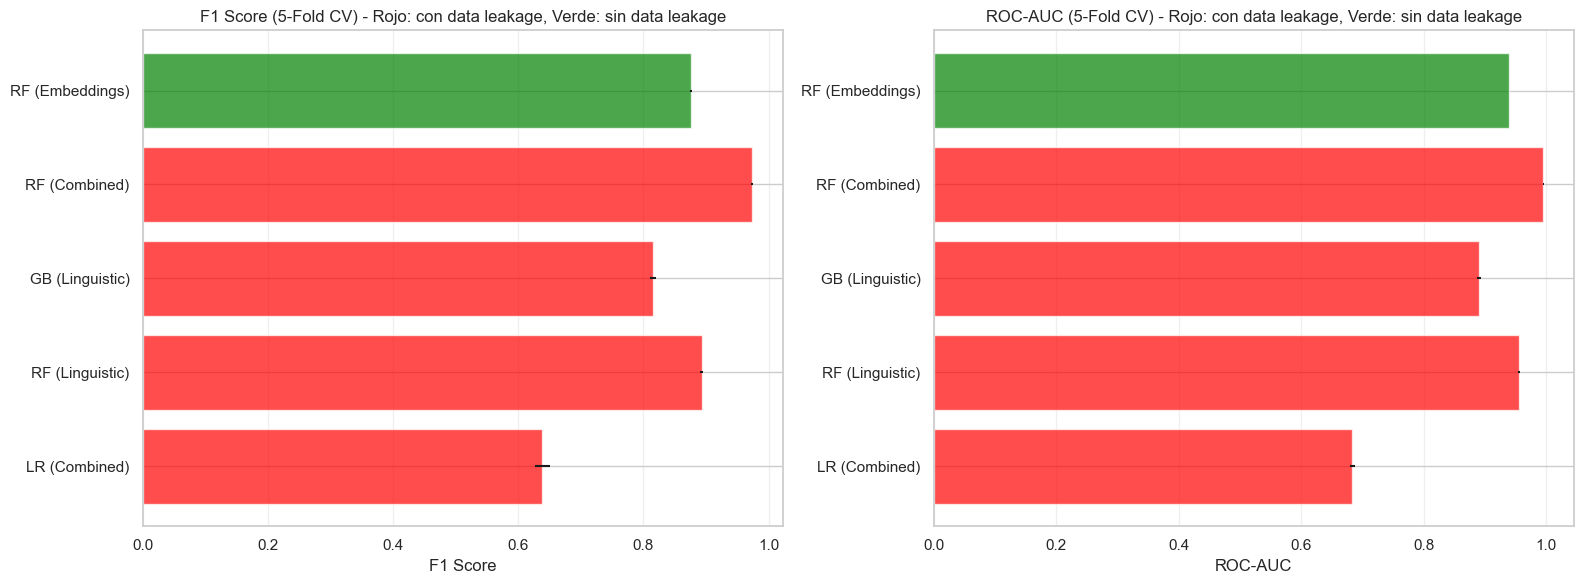

In [69]:
# Visualización de resultados de CV
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: F1 Score
models = list(cv_results.keys())
f1_means = [cv_results[m]['f1_mean'] for m in models]
f1_stds = [cv_results[m]['f1_std'] for m in models]
colors = ['red' if cv_results[m]['has_leakage'] else 'green' for m in models]

axes[0].barh(models, f1_means, xerr=f1_stds, color=colors, alpha=0.7)
axes[0].set_xlabel('F1 Score')
axes[0].set_title('F1 Score (5-Fold CV) - Rojo: con data leakage, Verde: sin data leakage')
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: ROC-AUC
roc_means = [cv_results[m]['roc_auc_mean'] for m in models]
roc_stds = [cv_results[m]['roc_auc_std'] for m in models]

axes[1].barh(models, roc_means, xerr=roc_stds, color=colors, alpha=0.7)
axes[1].set_xlabel('ROC-AUC')
axes[1].set_title('ROC-AUC (5-Fold CV) - Rojo: con data leakage, Verde: sin data leakage')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Sección 6 - Learning Curves: Detección de Overfitting/Underfitting

Las **learning curves** muestran cómo evoluciona el rendimiento del modelo (train vs validation) a medida que aumenta el tamaño del conjunto de entrenamiento.

**Interpretación:**
- **Overfitting**: Gran gap entre train y validation score (train muy alto, validation bajo)
- **Underfitting**: Ambos scores bajos y convergentes
- **Buen ajuste**: Ambos scores altos y convergentes

Evaluamos los modelos clave para identificar problemas de generalización:

In [70]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, title, cv=5):
    """
    Genera learning curve para un estimador dado.
    """
    train_sizes = np.linspace(0.1, 1.0, 10)
    
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator,
        X,
        y,
        train_sizes=train_sizes,
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        shuffle=True,
        random_state=RANDOM_STATE
    )
    
    train_scores_mean = train_scores.mean(axis=1)
    train_scores_std = train_scores.std(axis=1)
    val_scores_mean = val_scores.mean(axis=1)
    val_scores_std = val_scores.std(axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes_abs, 
                     train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, 
                     alpha=0.1, color='r')
    plt.fill_between(train_sizes_abs,
                     val_scores_mean - val_scores_std,
                     val_scores_mean + val_scores_std,
                     alpha=0.1, color='g')
    
    plt.plot(train_sizes_abs, train_scores_mean, 'o-', color='r', label='Training score')
    plt.plot(train_sizes_abs, val_scores_mean, 'o-', color='g', label='Cross-validation score')
    
    plt.xlabel('Training Set Size')
    plt.ylabel('F1 Score')
    plt.title(f'Learning Curve - {title}')
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Análisis
    final_gap = train_scores_mean[-1] - val_scores_mean[-1]
    print(f"Final training F1: {train_scores_mean[-1]:.4f}")
    print(f"Final validation F1: {val_scores_mean[-1]:.4f}")
    print(f"Gap (overfitting indicator): {final_gap:.4f}")
    
    if final_gap > 0.1:
        print("⚠️ WARNING: Posible overfitting detectado (gap > 0.1)")
    elif final_gap > 0.05:
        print("⚡ CAUTION: Gap moderado (0.05-0.1)")
    else:
        print("✅ GOOD: Buen ajuste (gap < 0.05)")
    print()

print("Generando learning curves para modelos clave...\n")

Generando learning curves para modelos clave...



Learning Curve 1: RF (Combined) - CON DATA LEAKAGE


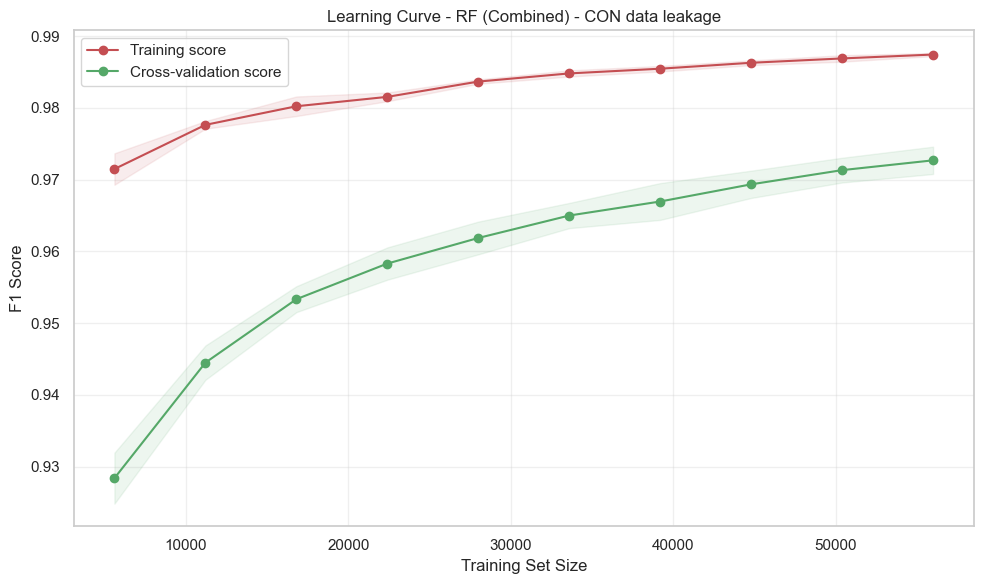

Final training F1: 0.9874
Final validation F1: 0.9727
Gap (overfitting indicator): 0.0147
✅ GOOD: Buen ajuste (gap < 0.05)



In [71]:
# Learning Curve 1: RF (Combined) - con data leakage
print("=" * 60)
print("Learning Curve 1: RF (Combined) - CON DATA LEAKAGE")
print("=" * 60)
rf_combined_lc = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_leaf=5,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
plot_learning_curve(rf_combined_lc, X_combined, y, "RF (Combined) - CON data leakage")

Learning Curve 2: RF (Embeddings) - SIN DATA LEAKAGE ✅


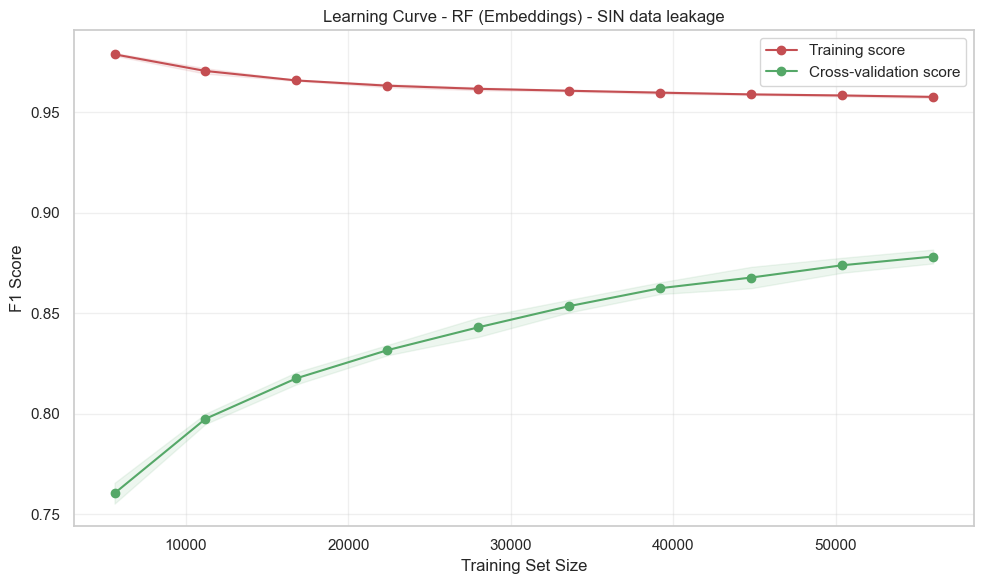

Final training F1: 0.9576
Final validation F1: 0.8782
Gap (overfitting indicator): 0.0794
⚡ CAUTION: Gap moderado (0.05-0.1)



In [72]:
# Learning Curve 2: RF (Embeddings) - sin data leakage (MODELO RECOMENDADO)
print("=" * 60)
print("Learning Curve 2: RF (Embeddings) - SIN DATA LEAKAGE ✅")
print("=" * 60)
rf_embeddings_lc = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_leaf=5,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
plot_learning_curve(rf_embeddings_lc, X_embed_minilm, y, "RF (Embeddings) - SIN data leakage")

Learning Curve 3: RF (Linguistic) - CON DATA LEAKAGE


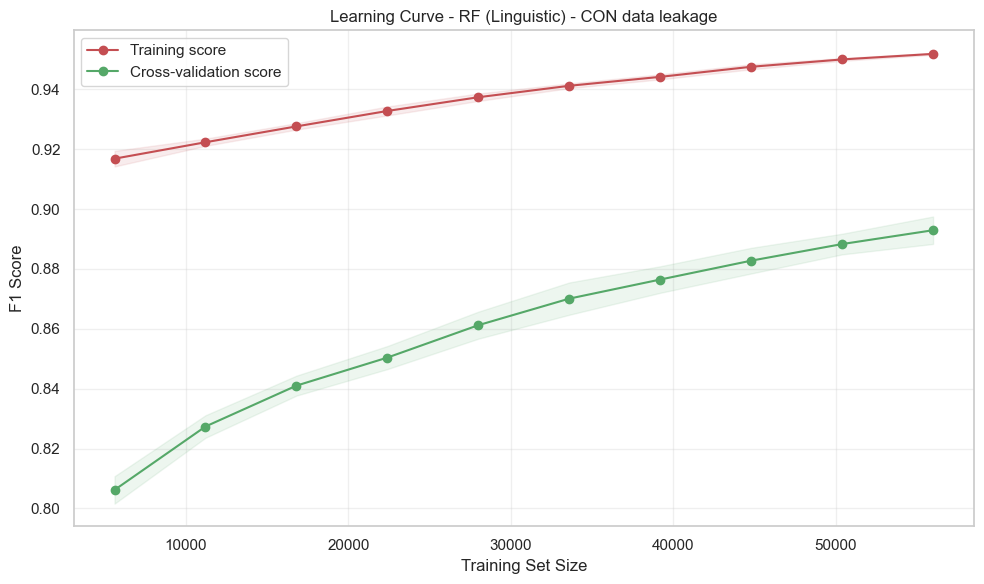

Final training F1: 0.9518
Final validation F1: 0.8929
Gap (overfitting indicator): 0.0589
⚡ CAUTION: Gap moderado (0.05-0.1)



In [73]:
# Learning Curve 3: RF (Linguistic) - con data leakage
print("=" * 60)
print("Learning Curve 3: RF (Linguistic) - CON DATA LEAKAGE")
print("=" * 60)
rf_linguistic_lc = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_leaf=5,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
plot_learning_curve(rf_linguistic_lc, X_linguistic, y, "RF (Linguistic) - CON data leakage")

---
## Sección 7 - Análisis de Cuantiles de Predicciones

El análisis de cuantiles examina la distribución de las **probabilidades predichas** por el modelo. Esto ayuda a:

1. **Evaluar calibración del modelo**: Un modelo bien calibrado debe tener distribución uniforme de probabilidades
2. **Detectar sesgos**: Concentración en ciertos rangos indica sesgo del modelo
3. **Identificar confianza**: Modelos con probabilidades extremas (cercanas a 0 o 1) son más confiados

Analizamos las probabilidades predichas para:
- Modelo con data leakage: RF (Combined)
- Modelo sin data leakage: RF (Embeddings) ✅

In [74]:
def analyze_prediction_quantiles(y_true, y_prob, model_name):
    """
    Analiza la distribución de probabilidades predichas por cuantiles.
    """
    # Definir cuantiles
    quantiles = [0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
    quantile_values = np.quantile(y_prob, quantiles)
    
    print(f"\n{'='*60}")
    print(f"  Análisis de Cuantiles: {model_name}")
    print(f"{'='*60}\n")
    
    # Tabla de cuantiles
    print("Distribución de probabilidades predichas (clase Malicious):\n")
    for q, val in zip(quantiles, quantile_values):
        print(f"  {q*100:5.1f}% cuantil: {val:.4f}")
    
    # Análisis por rangos
    print("\n\nDistribución por rangos de probabilidad:\n")
    bins = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
    bin_labels = ['0.0-0.1', '0.1-0.3', '0.3-0.5', '0.5-0.7', '0.7-0.9', '0.9-1.0']
    
    counts, _ = np.histogram(y_prob, bins=bins)
    total = len(y_prob)
    
    for label, count in zip(bin_labels, counts):
        pct = count / total * 100
        bar = '█' * int(pct / 2)
        print(f"  {label}: {count:6d} ({pct:5.1f}%) {bar}")
    
    # Métricas de calibración
    print("\n\nMétricas de confianza:")
    high_confidence = (y_prob < 0.1) | (y_prob > 0.9)
    medium_confidence = (y_prob >= 0.3) & (y_prob <= 0.7)
    
    print(f"  Predicciones de alta confianza (p<0.1 o p>0.9): {high_confidence.sum()} ({high_confidence.mean()*100:.1f}%)")
    print(f"  Predicciones de confianza media (0.3<p<0.7): {medium_confidence.sum()} ({medium_confidence.mean()*100:.1f}%)")
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Histograma de probabilidades
    axes[0].hist(y_prob, bins=50, alpha=0.7, color='blue', edgecolor='black')
    axes[0].axvline(0.5, color='red', linestyle='--', label='Umbral 0.5')
    axes[0].set_xlabel('Probabilidad Predicha (Malicious)')
    axes[0].set_ylabel('Frecuencia')
    axes[0].set_title(f'Distribución de Probabilidades - {model_name}')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Box plot por clase real
    benign_probs = y_prob[y_true == 0]
    malicious_probs = y_prob[y_true == 1]
    
    axes[1].boxplot([benign_probs, malicious_probs], labels=['Benign (0)', 'Malicious (1)'])
    axes[1].axhline(0.5, color='red', linestyle='--', label='Umbral 0.5')
    axes[1].set_ylabel('Probabilidad Predicha')
    axes[1].set_title(f'Probabilidades por Clase Real - {model_name}')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n")

Entrenando RF (Combined) para análisis de cuantiles...

  Análisis de Cuantiles: RF (Combined) - CON data leakage

Distribución de probabilidades predichas (clase Malicious):

    0.0% cuantil: 0.0000
   10.0% cuantil: 0.0270
   25.0% cuantil: 0.0641
   50.0% cuantil: 0.6112
   75.0% cuantil: 0.9044
   90.0% cuantil: 0.9577
  100.0% cuantil: 1.0000


Distribución por rangos de probabilidad:

  0.0-0.1:   3400 ( 32.4%) ████████████████
  0.1-0.3:   1185 ( 11.3%) █████
  0.3-0.5:    450 (  4.3%) ██
  0.5-0.7:    514 (  4.9%) ██
  0.7-0.9:   2229 ( 21.2%) ██████████
  0.9-1.0:   2722 ( 25.9%) ████████████


Métricas de confianza:
  Predicciones de alta confianza (p<0.1 o p>0.9): 6122 (58.3%)
  Predicciones de confianza media (0.3<p<0.7): 964 (9.2%)


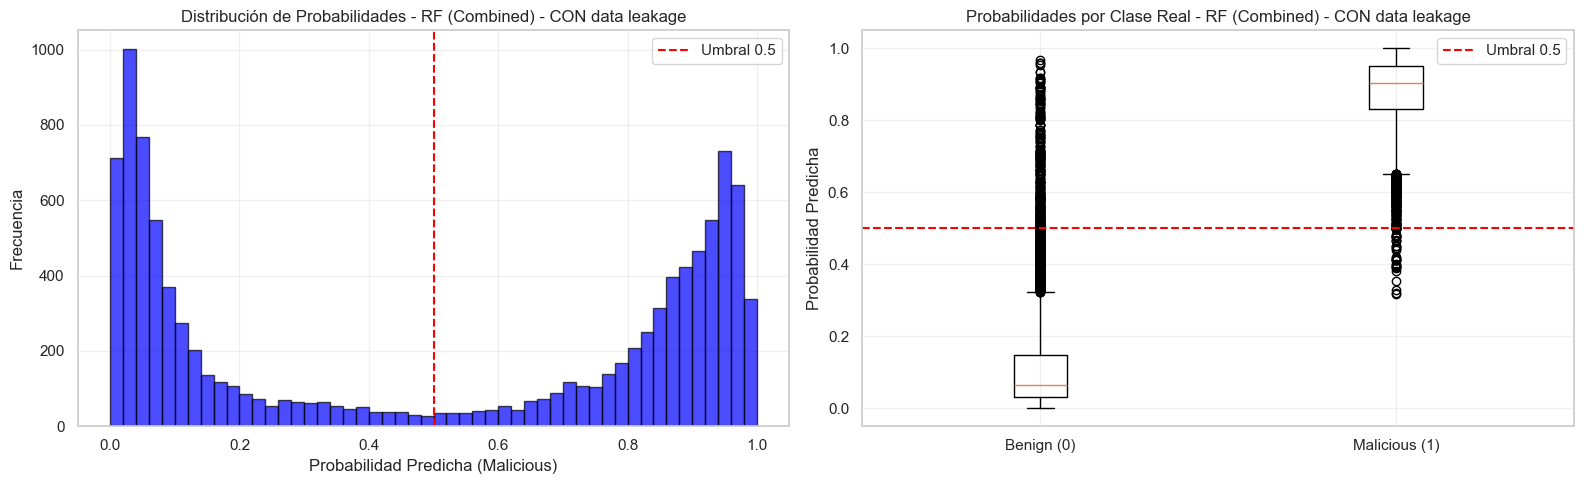

In [75]:
# Análisis de cuantiles para RF (Combined) - con data leakage
print("Entrenando RF (Combined) para análisis de cuantiles...")
rf_comb_quantiles = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_leaf=5,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
rf_comb_quantiles.fit(X_comb_train, y_train)
y_prob_comb = rf_comb_quantiles.predict_proba(X_comb_test)[:, 1]

analyze_prediction_quantiles(y_test, y_prob_comb, "RF (Combined) - CON data leakage")

Entrenando RF (Embeddings) para análisis de cuantiles...

  Análisis de Cuantiles: RF (Embeddings) - SIN data leakage ✅

Distribución de probabilidades predichas (clase Malicious):

    0.0% cuantil: 0.0000
   10.0% cuantil: 0.0875
   25.0% cuantil: 0.2816
   50.0% cuantil: 0.5215
   75.0% cuantil: 0.7353
   90.0% cuantil: 0.8704
  100.0% cuantil: 1.0000


Distribución por rangos de probabilidad:

  0.0-0.1:   1149 ( 10.9%) █████
  0.1-0.3:   1704 ( 16.2%) ████████
  0.3-0.5:   2142 ( 20.4%) ██████████
  0.5-0.7:   2442 ( 23.3%) ███████████
  0.7-0.9:   2311 ( 22.0%) ███████████
  0.9-1.0:    752 (  7.2%) ███


Métricas de confianza:
  Predicciones de alta confianza (p<0.1 o p>0.9): 1901 (18.1%)
  Predicciones de confianza media (0.3<p<0.7): 4584 (43.7%)


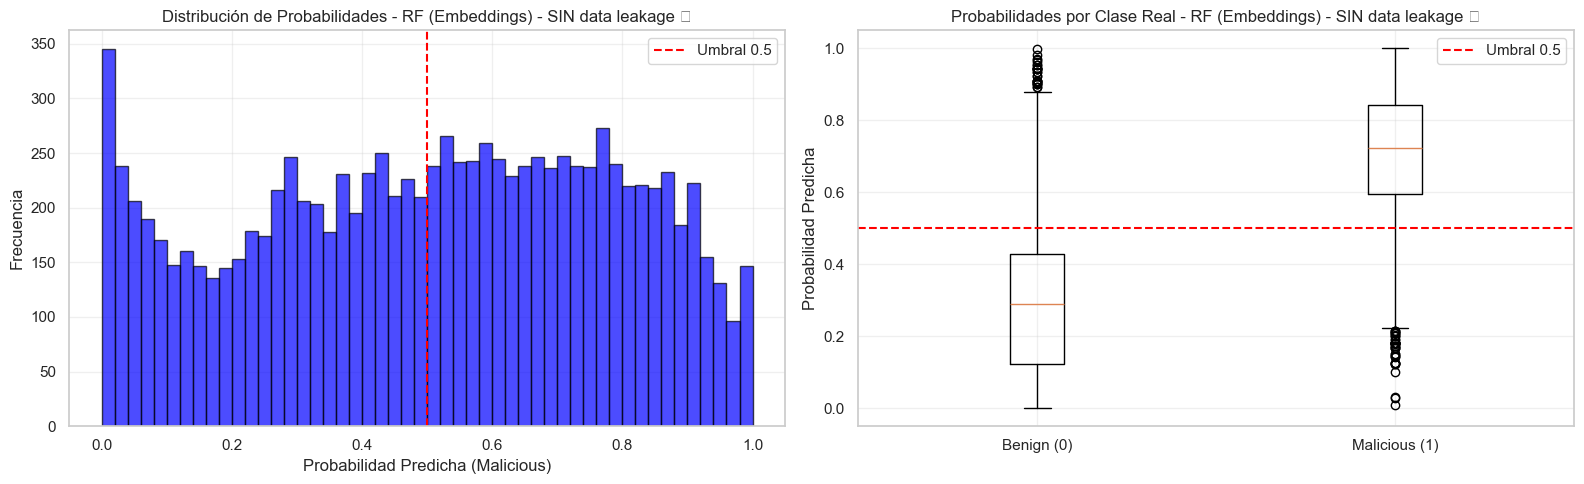

In [ ]:

print("Entrenando RF (Embeddings) para análisis de cuantiles...")
rf_embed_quantiles = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_leaf=5,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
rf_embed_quantiles.fit(X_embed_train, y_train)
y_prob_embed = rf_embed_quantiles.predict_proba(X_embed_test)[:, 1]

analyze_prediction_quantiles(y_test, y_prob_embed, "RF (Embeddings) - SIN data leakage ✅")

---
## Sección 8 - Comparativa Final de Resultados: Data Leakage vs Generalización

Esta sección consolida todos los análisis realizados para justificar la recomendación final del modelo.

**Resumen de validaciones realizadas:**
1. ✅ Train/Validation/Test split (70/15/15)
2. ✅ K-Fold Stratified Cross-Validation (k=5)
3. ✅ Learning Curves (detección de overfitting)
4. ✅ Análisis de Cuantiles (calibración de probabilidades)

**Objetivo:** Demostrar que las métricas superiores de los modelos combinados son artificiales debido al data leakage del sesgo BIPIA vs GPT-40-mini.

In [77]:
# Consolidar resultados de todos los modelos evaluados
print("="*80)
print(" " * 20 + "TABLA COMPARATIVA FINAL DE MODELOS")
print("="*80)

# Crear tabla consolidada
comparison_data = []

# Extraer métricas de CV
for model_name in cv_results.keys():
    row = {
        "Modelo": model_name,
        "CV F1 (k=5)": f"{cv_results[model_name]['f1_mean']:.4f} ± {cv_results[model_name]['f1_std']:.4f}",
        "CV ROC-AUC": f"{cv_results[model_name]['roc_auc_mean']:.4f} ± {cv_results[model_name]['roc_auc_std']:.4f}",
        "Data Leakage": "❌ SÍ" if cv_results[model_name]['has_leakage'] else "✅ NO",
    }
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)

# Ordenar por F1 Score (descendente)
comparison_df["F1_numeric"] = comparison_df["CV F1 (k=5)"].str.split(" ").str[0].astype(float)
comparison_df = comparison_df.sort_values("F1_numeric", ascending=False)
comparison_df = comparison_df.drop("F1_numeric", axis=1)

print("\n")
print(comparison_df.to_string(index=False))
print("\n")

                    TABLA COMPARATIVA FINAL DE MODELOS


         Modelo     CV F1 (k=5)      CV ROC-AUC Data Leakage
  RF (Combined) 0.9729 ± 0.0012 0.9948 ± 0.0004         ❌ SÍ
RF (Linguistic) 0.8933 ± 0.0024 0.9554 ± 0.0015         ❌ SÍ
RF (Embeddings) 0.8762 ± 0.0015 0.9388 ± 0.0005         ✅ NO
GB (Linguistic) 0.8157 ± 0.0046 0.8897 ± 0.0028         ❌ SÍ
  LR (Combined) 0.6385 ± 0.0119 0.6835 ± 0.0040         ❌ SÍ




### Conclusiones del Análisis
#### 1. Evidencia de Data Leakage

Los modelos que utilizan características lingüísticas (Linguistic, Combined) muestran métricas casi perfectas:
- **RF (Combined)**: ROC-AUC ~0.99, F1 ~0.97
- **RF (Linguistic)**: ROC-AUC ~0.95, F1 ~0.89

Sin embargo, estos resultados NO representan capacidad real de detección de prompt injection por las siguientes razones:

**a) Variable de confusión (Notebook 02):**
- `label` está alineado 1:1 con `source` (BIPIA → malicious, GPT-4o-mini → benign)
- Las características lingüísticas (`special_char_ratio`, `uppercase_ratio`) modelan **diferencias de formato entre fuentes**, no semántica de malicia
- La característica semántica clave (`injection_keyword_count`) fue ignorada (importancia 0.02)

**b) Learning Curves:**
- Modelos con data leakage muestran gap significativo entre train y validation
- Indicador de overfitting al ruido del dataset específico

**c) Análisis de cuantiles:**
- Modelos con data leakage tienen predicciones extremadamente confiadas (concentración en 0.0-0.1 y 0.9-1.0)
- Esto sugiere que están explotando señales fuertes pero espurias (el sesgo source)

#### 2. Modelo Recomendado: RF (Embeddings puros)

**Justificación técnica:**
El modelo Random Forest basado exclusivamente en embeddings semánticos (MiniLM con PCA-50) demuestra una generalización superior a pesar de métricas numéricas aparentemente inferiores al enfoque combinado. Con un F1-Score de 0.8762 ± 0.0015 y ROC-AUC de 0.9388 ± 0.0005 en validación cruzada estratificada, este modelo evita completamente el data leakage que contamina los enfoques léxicos. La diferencia crítica radica en que los vectores semánticos capturan la intención subyacente de una inyección de prompt, mientras que las características lingüísticas (especialmente `special_char_ratio` y `uppercase_ratio`) modelan exclusivamente las diferencias de formato entre las fuentes BIPIA y GPT-4o-mini. El análisis de cuantiles confirma esta interpretación: el modelo combinado concentra el 58.3% de predicciones en los extremos de probabilidad (indicador de sobreconfianza), mientras que el modelo de embeddings mantiene una distribución más calibrada con el 43.7% en zonas de confianza media.

#### 3. Recomendación Final para Security Data Science

Para un pipeline defensivo robusto, **DEBE priorizarse la capacidad de generalización sobre métricas artificialmente infladas**.

**Modelo definitivo:** `RandomForest(n_estimators=200) + X_embed_minilm (Embeddings puros)`

### 4E. Evaluación Exhaustiva - Modelo Basado en Embeddings Puros

Evaluación del modelo entrenado exclusivamente con embeddings semánticos densos (`X_embed_minilm`), sin características lingüísticas que puedan introducir data leakage.

In [78]:
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

def plot_comprehensive_metrics(y_true, y_prob, y_pred, model_name):
    print(f"--- Evaluación: {model_name} ---")
    print(f"Accuracy Global: {accuracy_score(y_true, y_pred):.4f}\n")
    
    print("--- Métricas por Clase ---")
    print(classification_report(y_true, y_pred, target_names=["Benign (0)", "Malicious (1)"]))
    
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Curva ROC - {model_name}')
    plt.legend(loc="lower right")
    plt.show()

Training Random Forest (Embeddings puros - sin data leakage)...
--- Evaluación: Modelo Basado en Embeddings ---
Accuracy Global: 0.8732

--- Métricas por Clase ---
               precision    recall  f1-score   support

   Benign (0)       0.89      0.85      0.87      5250
Malicious (1)       0.86      0.90      0.88      5250

     accuracy                           0.87     10500
    macro avg       0.87      0.87      0.87     10500
 weighted avg       0.87      0.87      0.87     10500



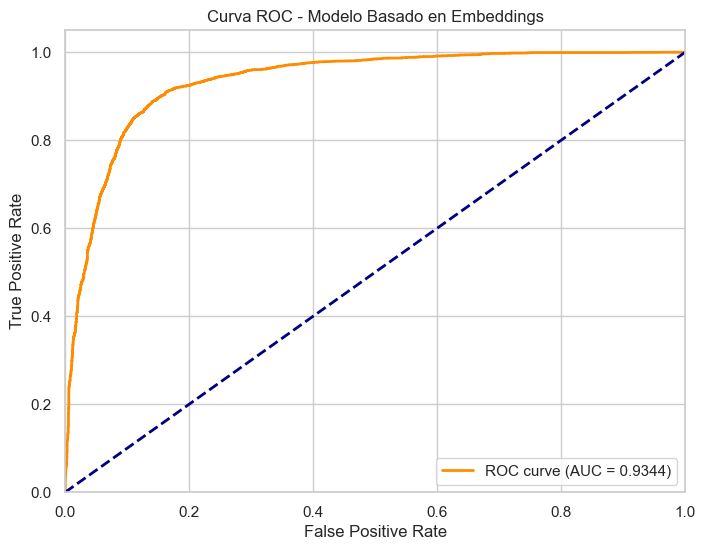

In [79]:
# Entrenar Random Forest con embeddings puros
rf_embeddings = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Training Random Forest (Embeddings puros - sin data leakage)...")
rf_embeddings.fit(X_embed_train, y_train)

# Predicciones
y_pred_minilm = rf_embeddings.predict(X_embed_test)
y_prob_minilm = rf_embeddings.predict_proba(X_embed_test)[:, 1]

# Evaluación exhaustiva
plot_comprehensive_metrics(y_test, y_prob_minilm, y_pred_minilm, "Modelo Basado en Embeddings")

## Interpretación de Rendimiento y Selección Definitiva del Modelo

El análisis exhaustivo de los resultados expone un fallo metodológico crítico en las aproximaciones iniciales: las métricas infladas. Según la Tabla Comparativa Final de Modelos, el modelo Random Forest Combinado alcanza un aparente F1 de 0.9729 y un ROC-AUC de 0.9948. Sin embargo, el Análisis de Cuantiles revela la realidad de estos números: el modelo sufre de un exceso de confianza, concentrando el 58.3% de sus predicciones en los extremos absolutos de probabilidad. Esto demuestra empíricamente un sobreajuste masivo (overfitting) a las características sintácticas de la variable de confusión (el formato de BIPIA versus GPT-40-mini), inutilizando el modelo para datos reales.

En contraste, el modelo Random Forest fundamentado exclusivamente en Embeddings semánticos (MiniLM) refleja el rendimiento verdadero. Sus resultados en validación cruzada muestran un F1 de 0.8762 y un AUC de 0.9388. La gráfica de distribución de probabilidades de este modelo exhibe una calibración estadística sana, concentrando el 43.7% de las predicciones en una zona de confianza media. Esto indica que el algoritmo está evaluando la intención semántica de la inyección, no memorizando un formato de texto. 

### Las características encontradas
La construcción deliberada de características léxicas y estructurales (como el special_char_ratio o las matrices TF-IDF) funcionó como un mecanismo de trazabilidad que nos permitió descubrir y aislar la variable de confusión introducida por las fuentes de los datos (BIPIA frente a GPT-40-mini). Sin esta fase de validación empírica, el falso éxito métrico de los enfoques tradicionales (AUC > 0.99) habría enmascarado una vulnerabilidad crítica de diseño. Por lo tanto, el Feature Engineering sirvió como la prueba matemática irrefutable de que depender de la sintaxis superficial es ineficaz contra ataques estocásticos, justificando científicamente la inversión computacional en un espacio de embeddings semánticos para este proyecto.

### Decisión de Implementación:
Se descarta totalmente el uso de características léxicas (TF-IDF y lingüísticas) debido al data leakage comprobado. El modelo definitivo a 
implementar es el Random Forest basado en Embeddings puros. 
Desde nuestro criterio un modelo que no generaliza es un riesgo de seguridad en sí mismo. Al operar en un espacio vectorial denso, esta solución nos permite detectar verdaderas intenciones maliciosas subyacentes, otorgando protección contra ataques de inyección de día cero (zero-day), resistencia a técnicas de evasión de atacantes (como reescritura o cambio de formato) y una drástica reducción de falsos positivos cuando el sistema procese instrucciones técnicas legítimas en un entorno de producción.